<a href="https://colab.research.google.com/github/KeerthanaSistla/Sem6DeepLearning/blob/main/DeepLearningSem6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introduction

Features of Deep Learning
*   Requires More amount of data
*   DL deals with non linear-data
*   Images, videos, audio and text
*   Complex model (hard to interpret)
*   Requires Graphical and Tenser Processing Units
*   Takes large computation
*   Automatic feature extractuion

PyTourch
*   Implimented  using LUA

TensorFlow
*   Implimented using C++, CUDA or Python

Keras
*   Implimented using Python

#Basic Coding

In [ ]:
import tensorflow as tf


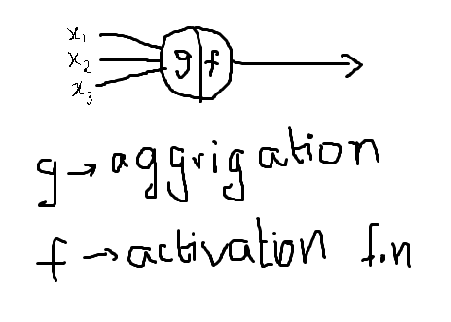

**g (aggrigation)** adds i.e., x1 + x2 + x3

**f (activation)** checks with condition
*   Step f.n, Sigmoid f.n, etc.
*   Fired if output is tangable

**Weights**
*   Priority of each input
*   g = x1w1 + x2w2 + x3w3

**Bias**
*   Adds non-linearity
*   Acts as a decision boundry

#Week 2

In [ ]:
import numpy as np

def step(x):
  return 1 if x >= 0 else 0

class Perceptron:
  def __init__(self, weights, bias):
    self.weights = weights
    self.bias = bias

  def predict(self, inputs):
              z = np.dot(self.weights, inputs)+self.bias
              return step(z)

#AND Operation
weights = np.array([1, 1])
bias = -1.5

and_gate = Perceptron(weights, bias)

print("AND Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", and_gate.predict(np.array(x)))

#OR Operation
weights = np.array([1, 1])
bias = -0.5

or_gate = Perceptron(weights, bias)

print("OR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", or_gate.predict(np.array(x)))

AND Gate
(0, 0) -> 0
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1
OR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1


In [ ]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class XOR_network:
    def __init__(self):
        self.w_or = np.array([1, 1])
        self.b_or = -0.5

        self.w_and = np.array([1, 1])
        self.b_and = -1.5

        self.w_out = np.array([1, -2])
        self.b_out = -0.5

    def predict(self, x):
        h1 = step(np.dot(self.w_or, x) + self.b_or)
        h2 = step(np.dot(self.w_and, x) + self.b_and)
        output = step(np.dot(self.w_out, [h1, h2]) + self.b_out)
        return output

xor = XOR_network()

print("XOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xor.predict(np.array(x)))

XOR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0


In [ ]:
# ~XOR Function

import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class XOR_network:
    def __init__(self):
        self.w_or = np.array([1, 1])
        self.b_or = -0.5

        self.w_and = np.array([1, 1])
        self.b_and = -1.5

        self.w_out = np.array([1, -2])
        self.b_out = -0.5

    def predict(self, x):
        h1 = step(np.dot(self.w_or, x) + self.b_or)
        h2 = step(np.dot(self.w_and, x) + self.b_and)
        return step(np.dot(self.w_out, [h1, h2]) + self.b_out)

class XNOR_network(XOR_network):
    def predict(self, x):
        return 1 - super().predict(x)

xnor = XNOR_network()

print("XNOR Gate")
for x in [(0,0),(0,1),(1,0),(1,1)]:
    print(x, "->", xnor.predict(np.array(x)))

XNOR Gate
(0, 0) -> 1
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


In [ ]:
# Harsh Threshold
import numpy as np

def step(x):
  return 1 if x >= 0 else 0

class Neuron:
  def __init__(self, weights, bias):
    self.weights = weights
    self.bias = bias
  def feedforward(self, inputs):
    total = np.dot(self.weights, inputs) + self.bias
    return step(total)

weights = np.array([0, 1])
b_1 = -3.1
b_2 = 2
b_3 = -3.0

n = Neuron(weights, b_1)
n_2 = Neuron(weights, b_2)
n_3 = Neuron(weights,b_3)

x = np.array([2, 3])

print("with bias -3.1:",n.feedforward(x))
print("\nwith bias -3.0:",n_3.feedforward(x))
print("\nwith bias 2:",n_2.feedforward(x))

with bias -3.1: 0

with bias -3.0: 1

with bias 2: 1


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("movies.csv")

X = data[['f1', 'f2', 'f3', 'f4']].values
y = data['label'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

learning_rate = 0.01
epochs = 50
weights = np.zeros(X.shape[1])
bias = 0.0

def step_function(z):
    return 1 if z >= 0 else 0

for epoch in range(epochs):
    total_errors = 0

    indices = np.random.permutation(len(X))

    for i in indices:
        linear_output = np.dot(X[i], weights) + bias
        y_pred = step_function(linear_output)

        error = y[i] - y_pred

        if error != 0:
            weights += learning_rate * error * X[i]
            bias += learning_rate * error
            total_errors += 1

    print(
        f"Epoch {epoch+1:02d} | "
        f"Errors: {total_errors} | "
        f"Weights: {weights.round(3)} | "
        f"Bias: {round(bias, 3)}"
    )

    if total_errors == 0:
        print("\nConverged")
        break

print("\nFinal Weights:", weights)
print("Final Bias:", bias)

Epoch 01 | Errors: 4 | Weights: [0.    0.    0.    0.028] | Bias: 0.0
Epoch 02 | Errors: 2 | Weights: [ 0.     0.    -0.02   0.032] | Bias: 0.0
Epoch 03 | Errors: 2 | Weights: [ 0.     0.    -0.     0.048] | Bias: 0.0
Epoch 04 | Errors: 1 | Weights: [ 0.01  -0.01  -0.008  0.047] | Bias: 0.01
Epoch 05 | Errors: 0 | Weights: [ 0.01  -0.01  -0.008  0.047] | Bias: 0.01

Converged

Final Weights: [ 0.01       -0.01       -0.00816497  0.04699912]
Final Bias: 0.01


In [ ]:
import itertools
import numpy as np

class Perceptron:
    def __init__(self, lr=0.1, epochs=100):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0

        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                output = self.predict(xi)
                update = self.lr * (target - output)
                if update != 0:
                    self.w += update * xi
                    self.b += update
                    errors += 1
            if errors == 0:
                return True   # converged
        return False          # did not converge

    def predict(self, x):
        return 1 if np.dot(x, self.w) + self.b >= 0 else 0

def generate_boolean_functions(n):
    inputs = np.array(list(itertools.product([0, 1], repeat=n)))
    functions = list(itertools.product([0, 1], repeat=2**n))
    return inputs, functions

def test_perceptron(n):
    X, functions = generate_boolean_functions(n)
    perceptron = Perceptron()
    not_learnable = 0

    for f in functions:
        y = np.array(f)
        learned = perceptron.fit(X, y)
        if not learned:
            not_learnable += 1

    total = len(functions)
    print(f"Inputs: {n}")
    print(f"Total Boolean functions: {total}")
    print(f"Not learnable by perceptron: {not_learnable}")
    print(f"Learnable: {total - not_learnable}\n")

def theoretical_results(n):
    known = {
        4: (65536, 1882),
        5: (2**32, 94572)
    }

    if n in known:
        total, linear = known[n]
        print(f"Inputs: {n}")
        print(f"Total Boolean functions: {total}")
        print(f"Learnable (linearly separable): {linear}")
        print(f"Not learnable: {total - linear}\n")
    else:
        print(f"Inputs: {n}")
        print("Total Boolean functions grow as 2^(2^n)")
        print("Almost all Boolean functions are non-linearly separable\n")

if __name__ == "__main__":

    # Brute-force (safe)
    test_perceptron(2)
    test_perceptron(3)

    # Theory-based (avoids infinite runtime)
    for n in range(4, 6):
        theoretical_results(n)

Inputs: 2
Total Boolean functions: 16
Not learnable by perceptron: 2
Learnable: 14

Inputs: 3
Total Boolean functions: 256
Not learnable by perceptron: 152
Learnable: 104

Inputs: 4
Total Boolean functions: 65536
Learnable (linearly separable): 1882
Not learnable: 63654

Inputs: 5
Total Boolean functions: 4294967296
Learnable (linearly separable): 94572
Not learnable: 4294872724



In [ ]:
# How many Boolean functions can be designed using three binary inputs?
import itertools
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

X = np.array(list(itertools.product([0, 1], repeat=3)))

boolean_functions = list(itertools.product([0, 1], repeat=8))


class BooleanMLP:
    def __init__(self):
        self.hidden_weights = []
        self.hidden_biases = []

        for pattern in X:
            w = np.array([1 if bit == 1 else -1 for bit in pattern])
            b = -sum(pattern) + 0.5
            self.hidden_weights.append(w)
            self.hidden_biases.append(b)

    def forward(self, x, output_weights):
        hidden_outputs = []
        for w, b in zip(self.hidden_weights, self.hidden_biases):
            hidden_outputs.append(step(np.dot(w, x) + b))

        return step(np.dot(output_weights, hidden_outputs) - 0.5)

mlp = BooleanMLP()
successful = 0

for f in boolean_functions:
    output_weights = np.array(f)
    correct = True

    for x, target in zip(X, f):
        y = mlp.forward(x, output_weights)
        if y != target:
            correct = False
            break

    if correct:
        successful += 1

print(f"Total Boolean functions: {len(boolean_functions)}")
print(f"Functions perfectly represented: {successful}")

Total Boolean functions: 256
Functions perfectly represented: 256


#Week 3

#Week 4

In [3]:
#USING OPTIMIZATION ALGO
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import altair as alt

y = np.array([[0, 1, 1, 0]]).T

X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

model = Sequential()
model.add(Dense(16, input_dim=2, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='mean_squared_error',
              optimizer='adam',
              metrics=['binary_accuracy', 'mean_squared_error'])

history = model.fit(X, y, epochs=1000, verbose=0)

errors = history.history['loss']

df2 = pd.DataFrame({"errors":errors, "time-step": np.arange(0, len(errors))})

alt.Chart(df2).mark_line().encode(x="time-step", y="errors").properties(title='Chart 3')

y_pred = model.predict(X).round()
num_correct_predictions = (y_pred == y).sum()
accuracy = (num_correct_predictions / y.shape[0]) * 100
print('Multi-layer perceptron accuracy: %.2f%%' % accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Multi-layer perceptron accuracy: 100.00%


In [5]:
#USING SGD OPTIMIZATION ALGO
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import altair as alt

y = np.array([[0, 1, 1, 0]]).T

X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

model = Sequential()
model.add(Dense(16, input_dim=2, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='mean_squared_error',
              optimizer=SGD(),
              metrics=['binary_accuracy', 'mean_squared_error'])

history = model.fit(X, y, epochs=1000, verbose=0)

errors = history.history['loss']

df2 = pd.DataFrame({"errors":errors, "time-step": np.arange(0, len(errors))})

alt.Chart(df2).mark_line().encode(x="time-step", y="errors").properties(title='Chart 3')

y_pred = model.predict(X).round()
num_correct_predictions = (y_pred == y).sum()
accuracy = (num_correct_predictions / y.shape[0]) * 100
print('Multi-layer perceptron accuracy: %.2f%%' % accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Multi-layer perceptron accuracy: 50.00%


In [7]:
# Using MGD (Momentum Gradient Descent) Optimizer
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import altair as alt
from tensorflow.keras.optimizers import SGD
# expected values
y = np.array([[0, 1, 1, 0]]).T

# features
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T
model_mgd = Sequential()
model_mgd.add(Dense(16, input_dim=2, activation='sigmoid'))
model_mgd.add(Dense(1, activation='sigmoid'))

model_mgd.compile(loss='mean_squared_error',
                  optimizer=SGD(momentum=0.1),
                  metrics=['binary_accuracy', 'mean_squared_error'])

history_mgd = model_mgd.fit(X, y, epochs=1000, verbose=0)

errors_mgd = history_mgd.history['loss']

df_mgd = pd.DataFrame({"errors": errors_mgd, "time-step": np.arange(0, len(errors_mgd))})

alt.Chart(df_mgd).mark_line().encode(x="time-step", y="errors").properties(title='MGD Optimizer - Loss Curve')

y_pred_mgd = model_mgd.predict(X).round()
num_correct_predictions_mgd = (y_pred_mgd == y).sum()
accuracy_mgd = (num_correct_predictions_mgd / y.shape[0]) * 100
print('MGD Optimizer accuracy: %.2f%%' % accuracy_mgd)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
MGD Optimizer accuracy: 50.00%
